In [1]:
% Create Figure 15
clear
close all
load ChristmasSales.mat
Ntable=ChristmasSales;
prin=0;
% Simultaneous confidence level to use
conflevSim=0.99;
I=size(Ntable,1);
conflev=1-(1-conflevSim)/I;


fimdEmp=struct;
findEmp.StoreSim=true;
findEmp.nsimul=100;
% Store the nsimul robust distance sorted (for each row)


% Under the null hypothesis of independence
findEmp.underH0=true;
% call to mcdCorAna
RAWH0=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev);

Finding empirical bands

In [2]:
outFSH0=FSCorAna(RAWH0,'plots',0,'msg',0,'StoreSim',false,'conflev',conflevSim);


% Under the alternative
findEmp.underH0=false;
% call to mcdCorAna
RAWH1=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev);

Finding empirical bands

In [3]:
outFSH1=FSCorAna(RAWH1,'plots',0,'msg',0,'StoreSim',false,'conflev',conflevSim);


## Create Figure 15


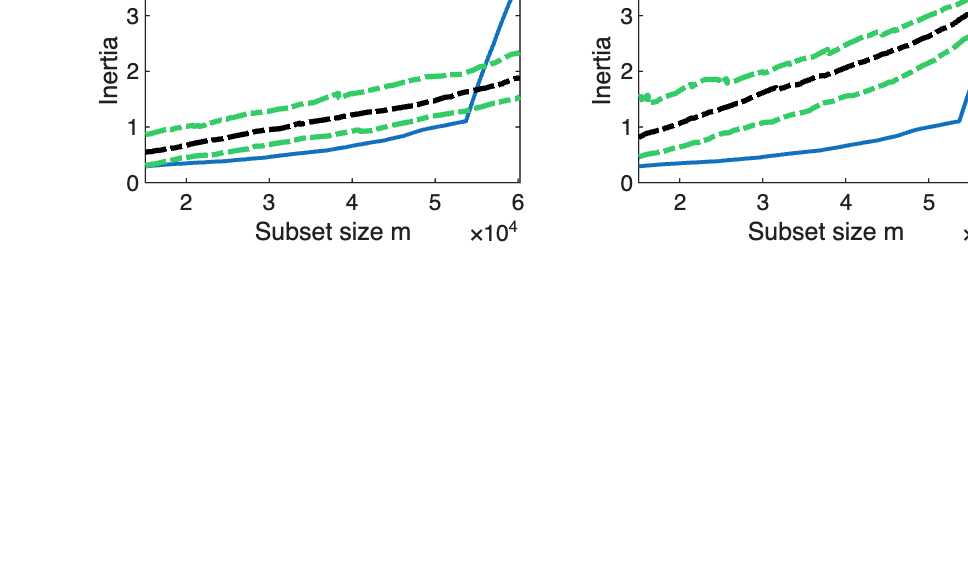

In [4]:
lwdreal=1.5;
subplot(2,2,1)
plot(outFSH0.ine(:,1),outFSH0.ine(:,2),'LineWidth',lwdreal)
gineH0=outFSH0.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gineH0(:,1),gineH0(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gineH0(:,1),gineH0(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gineH0(:,1),gineH0(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
ylabel('Inertia')
xlabel('Subset size m')


subplot(2,2,2)
plot(outFSH1.ine(:,1),outFSH1.ine(:,2),'LineWidth',lwdreal)


hold on
gineH1=outFSH1.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gineH1(:,1),gineH1(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gineH1(:,1),gineH1(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gineH1(:,1),gineH1(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');


ylabel('Inertia')
xlabel('Subset size m')

In [5]:


if prin==1
    print -depsc figs\I7.eps;
end